In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
import tensorflow as tf

In [ ]:
device='cuda' if torch.cuda.is_available else 'cpu'
print(device)

cuda


In [ ]:
# Reading the dataset from pandas
import pandas as pd

df = pd.read_csv("hf://datasets/merve/poetry/poetry.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
print(df.head())

                                    author  \
0                      WILLIAM SHAKESPEARE   
1  DUCHESS OF NEWCASTLE MARGARET CAVENDISH   
2                           THOMAS BASTARD   
3                           EDMUND SPENSER   
4                        RICHARD BARNFIELD   

                                             content  \
0  Let the bird of loudest lay\r\nOn the sole Ara...   
1  Sir Charles into my chamber coming in,\r\nWhen...   
2  Our vice runs beyond all that old men saw,\r\n...   
3  Lo I the man, whose Muse whilome did maske,\r\...   
4  Long have I longd to see my love againe,\r\nSt...   

                                 poem name          age                  type  
0               The Phoenix and the Turtle  Renaissance  Mythology & Folklore  
1                 An Epilogue to the Above  Renaissance  Mythology & Folklore  
2                       Book 7, Epigram 42  Renaissance  Mythology & Folklore  
3  from The Faerie Queene: Book I, Canto I  Renaissance  Mythology

In [ ]:
# Creating Dataset
Dataset=df.iloc[:,1]
print(Dataset.head())

0    Let the bird of loudest lay\r\nOn the sole Ara...
1    Sir Charles into my chamber coming in,\r\nWhen...
2    Our vice runs beyond all that old men saw,\r\n...
3    Lo I the man, whose Muse whilome did maske,\r\...
4    Long have I longd to see my love againe,\r\nSt...
Name: content, dtype: object


In [ ]:
# Attaching SOS and EOS tokens to the poem
all_words=[]
maxlen=0
ds=[]
for i in Dataset:
  words_in_poem=i.split()
  words_in_poem=['<SOS>'] +  words_in_poem + ['<EOS>']
  ds.append(words_in_poem)
  if maxlen<len(words_in_poem):
    maxlen=len(words_in_poem)
  for k in words_in_poem:
    all_words.append(k)

In [ ]:
# Finding total number of distinct words in the dataset
preprocessed=list(set(all_words))
print(len(all_words))
print(Dataset.shape)
print(all_words[:35])
print(maxlen)
print(len(preprocessed))
print(ds[:2])

100499
(573,)
['<SOS>', 'Let', 'the', 'bird', 'of', 'loudest', 'lay', 'On', 'the', 'sole', 'Arabian', 'tree', 'Herald', 'sad', 'and', 'trumpet', 'be,', 'To', 'whose', 'sound', 'chaste', 'wings', 'obey.', 'But', 'thou', 'shrieking', 'harbinger,', 'Foul', 'precurrer', 'of', 'the', 'fiend,', 'Augur', 'of', 'the']
4344
18831
[['<SOS>', 'Let', 'the', 'bird', 'of', 'loudest', 'lay', 'On', 'the', 'sole', 'Arabian', 'tree', 'Herald', 'sad', 'and', 'trumpet', 'be,', 'To', 'whose', 'sound', 'chaste', 'wings', 'obey.', 'But', 'thou', 'shrieking', 'harbinger,', 'Foul', 'precurrer', 'of', 'the', 'fiend,', 'Augur', 'of', 'the', "fever's", 'end,', 'To', 'this', 'troop', 'come', 'thou', 'not', 'near.', 'From', 'this', 'session', 'interdict', 'Every', 'fowl', 'of', 'tyrant', 'wing,', 'Save', 'the', 'eagle,', "feather'd", 'king;', 'Keep', 'the', 'obsequy', 'so', 'strict.', 'Let', 'the', 'priest', 'in', 'surplice', 'white,', 'That', 'defunctive', 'music', 'can,', 'Be', 'the', 'death-divining', 'swan,', '

In [ ]:
# Using in-built tokenizer in keras library which does white space tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

tokenizer = Tokenizer(lower=False)
tokenizer.fit_on_texts(ds)
sequences=tokenizer.texts_to_sequences(ds)
pad_seq=pad_sequences(sequences,maxlen=4344,padding='post')

In [ ]:
tensor_dataset = torch.tensor(pad_seq, dtype=torch.long)

In [ ]:
# Test train split
from sklearn.model_selection import train_test_split
import numpy as np
ds_array=np.array(pad_seq)
train , test = train_test_split(ds_array,test_size=0.3,random_state=42)

In [ ]:
# counts=torch.zeros((18831,18831))
# id_dic=tokenizer.word_index
# for poems in train:
#   for w1 , w2 in zip(train , train[1:]):
#     idx1=id_dic.get(w1)
#     idx2=id_dic.get(w2)
#     counts[idx1,idx2]+=1

# Took help of LLM for optimized way to do this in less time the above one took 2hrs for no output
from collections import defaultdict , Counter
bigram_counts=defaultdict(Counter)

token_ids = [token for seq in train for token in seq]
for i in range(len(token_ids) - 1):
    w1 = token_ids[i]
    w2 = token_ids[i+1]
    bigram_counts[w1][w2] += 1


In [ ]:
print(bigram_counts[14])

Counter({np.int32(33): 9, np.int32(64): 6, np.int32(1254): 6, np.int32(817): 6, np.int32(142): 6, np.int32(636): 6, np.int32(219): 6, np.int32(312): 5, np.int32(759): 4, np.int32(1255): 4, np.int32(419): 4, np.int32(354): 4, np.int32(138): 4, np.int32(322): 4, np.int32(750): 4, np.int32(992): 4, np.int32(984): 4, np.int32(294): 4, np.int32(380): 3, np.int32(361): 3, np.int32(3666): 3, np.int32(127): 3, np.int32(755): 3, np.int32(4434): 3, np.int32(682): 3, np.int32(4464): 3, np.int32(243): 3, np.int32(599): 2, np.int32(972): 2, np.int32(133): 2, np.int32(293): 2, np.int32(7419): 2, np.int32(4325): 2, np.int32(1908): 2, np.int32(6241): 2, np.int32(154): 2, np.int32(802): 2, np.int32(7599): 2, np.int32(1169): 2, np.int32(136): 2, np.int32(700): 2, np.int32(2242): 2, np.int32(244): 2, np.int32(713): 2, np.int32(7699): 2, np.int32(1443): 2, np.int32(6058): 2, np.int32(172): 2, np.int32(304): 2, np.int32(4767): 2, np.int32(3332): 2, np.int32(246): 2, np.int32(4264): 2, np.int32(7862): 2, np

In [ ]:
# Inference loop
import random
correct_pred=0
total_pred=0
id_dic=tokenizer.word_index
for seq in test:
  current_token= id_dic['<SOS>']
  for i in range(maxlen-1):
    if (seq[i+1]==0):
      break
    # This is for OOV handling added using LLM to take care of words that are not seen since I made frequencies to the words in train but not in test
    if current_token not in bigram_counts or not bigram_counts[current_token]:
      total_pred += 1
      current_token = seq[i+1]
      continue
    next_tokens=list(bigram_counts[current_token].keys())
    frequencies=list(bigram_counts[current_token].values())
    pred_token=random.choices(next_tokens,weights=frequencies,k=1)[0]
    if(pred_token==seq[i+1]):
      correct_pred+=1
    total_pred+=1
    current_token=seq[i+1] # Teacher forcing has been added using LLM thoughts it says it's required for the model to predict what I want but not what it can
print(f"Accuracy:{correct_pred*100/total_pred}")

Accuracy:8.679836939479461


In [ ]:
# Transforming the Dataset so that I can do character level tokenization and keeping single token for start , end and padding
ds_trans=[]
all_words_trans=[]
for i in Dataset:
  words_in_poem=i.split()
  words_in_poem=['0'] +  words_in_poem + ['0']
  ds_trans.append(words_in_poem)
  for k in words_in_poem:
    all_words_trans.append(k)
preprocessed_trans=list(set(all_words_trans))
print(len(preprocessed_trans))
print(ds_trans[:2])

18830
[['0', 'Let', 'the', 'bird', 'of', 'loudest', 'lay', 'On', 'the', 'sole', 'Arabian', 'tree', 'Herald', 'sad', 'and', 'trumpet', 'be,', 'To', 'whose', 'sound', 'chaste', 'wings', 'obey.', 'But', 'thou', 'shrieking', 'harbinger,', 'Foul', 'precurrer', 'of', 'the', 'fiend,', 'Augur', 'of', 'the', "fever's", 'end,', 'To', 'this', 'troop', 'come', 'thou', 'not', 'near.', 'From', 'this', 'session', 'interdict', 'Every', 'fowl', 'of', 'tyrant', 'wing,', 'Save', 'the', 'eagle,', "feather'd", 'king;', 'Keep', 'the', 'obsequy', 'so', 'strict.', 'Let', 'the', 'priest', 'in', 'surplice', 'white,', 'That', 'defunctive', 'music', 'can,', 'Be', 'the', 'death-divining', 'swan,', 'Lest', 'the', 'requiem', 'lack', 'his', 'right.', 'And', 'thou', 'treble-dated', 'crow,', 'That', 'thy', 'sable', 'gender', "mak'st", 'With', 'the', 'breath', 'thou', "giv'st", 'and', "tak'st,", "'Mongst", 'our', 'mourners', 'shalt', 'thou', 'go.', 'Here', 'the', 'anthem', 'doth', 'commence:', 'Love', 'and', 'constancy'

In [ ]:
## Charecter level Tokenizer
class CharTokenizer:
  def __init__(self,dataset):
    self.chars=dataset
    self.vocab_size=len(self.chars)
    self.stoi = {ch: i for i, ch in enumerate(self.chars)}
    self.itos = {i: ch for i, ch in enumerate(self.chars)}

  def encode(self,poem_as_list_of_words):
    encoded_chars_flat = []
    for word in poem_as_list_of_words:
      for char in word:
        encoded_chars_flat.append(self.stoi[char])
    return encoded_chars_flat

  # def decode(self,seq):
  #   return ''.join([self.itos[token] for token in seq])


# Used LLM to write the correct code before it printed generator object which I was unable to solve
all_unique_chars = set()
for word in preprocessed_trans:
  for char in word:
    all_unique_chars.add(char)

final_list = sorted(list(all_unique_chars))

print(final_list)
print(len(final_list))
tokenizer1=CharTokenizer(final_list)
print(tokenizer1.vocab_size)
encoded=tokenizer1.encode(ds_trans[0])
print(encoded)
print(len(encoded))

['!', '"', '&', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']
80
80
[10, 34, 56, 71, 71, 59, 56, 53, 60, 69, 55, 66, 57, 63, 66, 72, 55, 56, 70, 71, 63, 52, 76, 37, 65, 71, 59, 56, 70, 66, 63, 56, 23, 69, 52, 53, 60, 52, 65, 71, 69, 56, 56, 30, 56, 69, 52, 63, 55, 70, 52, 55, 52, 65, 55, 71, 69, 72, 64, 67, 56, 71, 53, 56, 6, 42, 66, 74, 59, 66, 70, 56, 70, 66, 72, 65, 55, 54, 59, 52, 70, 71, 56, 74, 60, 65, 58, 70, 66, 53, 56, 76, 8, 24, 72, 71, 71, 59, 66, 72, 70, 59, 69, 60, 56, 62, 60, 65, 58, 59, 52, 69, 53, 60, 65, 58, 56, 69, 6, 28, 66, 72, 63, 67, 69, 56, 54, 72, 69, 69, 56, 69, 66, 57, 71, 59, 56, 57, 60, 56, 65, 55, 6, 23, 72, 58, 72, 69, 66, 

In [ ]:
# Formed chunks to remove the problem with RAM before it showed an error saying insufficient RAM
TRANSFORMER_MAX_SEQ_LEN = 512
padding_token_id = tokenizer1.stoi['0']

In [ ]:
# Forming chunks and creating proper dataset
ds_processed_chunks = []

for poem in ds_trans:
    encoded_poem = tokenizer1.encode(poem)

    if len(encoded_poem) <= TRANSFORMER_MAX_SEQ_LEN:
        padded_sequence = encoded_poem + [padding_token_id] * (TRANSFORMER_MAX_SEQ_LEN - len(encoded_poem))
        ds_processed_chunks.append(padded_sequence)
    else:
        for i in range(0, len(encoded_poem)):
            chunk = encoded_poem[i : i + TRANSFORMER_MAX_SEQ_LEN]
            if len(chunk) < TRANSFORMER_MAX_SEQ_LEN:
                chunk = chunk + [padding_token_id] * (TRANSFORMER_MAX_SEQ_LEN - len(chunk))
            ds_processed_chunks.append(chunk)

ds_final_tensor = torch.tensor(ds_processed_chunks, dtype=torch.long,device=device)

print(len(ds_final_tensor))
print(ds_final_tensor.shape)

326569
torch.Size([326569, 512])


In [ ]:
# ds_encoded=[]
# max_len=0
# for i in ds_trans:
#   encoded=tokenizer1.encode(i)
#   ds_encoded.append(encoded)
#   if max_len<len(encoded):
#     max_len=len(encoded)
# print(max_len)

In [ ]:
# for poem in ds_encoded:
#   if len(poem)<max_len:
#     for _ in range(max_len-len(poem)):
#       poem.append(10)

In [ ]:
## Transformer model
# Class 1 - Embedding
class Embeddings(nn.Module):
  def __init__(self,input_dim,emb_dim):
    super().__init__()
    self.emb=nn.Embedding(input_dim,emb_dim)

  def forward(self,x):
    return self.emb(x)

In [ ]:
# Positional Encoding
class Positional_encoding(nn.Module):
  def __init__(self,max_len,dim):
    super().__init__()
    pe=torch.zeros(max_len,dim)
    position=torch.arange(0,max_len).unsqueeze(1)
    div_term=torch.exp(torch.arange(0,dim,2).float() * -1 * (torch.log(torch.tensor(10000))/dim))
    pe[:,0::2]=torch.sin(position*div_term)
    pe[:,1::2]=torch.cos(position*div_term)
    self.register_buffer('pe',pe.unsqueeze(0))

  def forward(self,x):
    return x+self.pe[:,:x.size(1),:]

In [ ]:
# Multi Head Attention
class Multi_Head_Attention(nn.Module):
  def __init__(self,d_model,num_heads):
    super().__init__()
    self.w_q=nn.Linear(d_model,d_model)
    self.w_k=nn.Linear(d_model,d_model)
    self.w_v=nn.Linear(d_model,d_model)
    self.w_o=nn.Linear(d_model,d_model)
    self.d_model=d_model
    self.d_k=d_model//num_heads
    self.num_heads=num_heads

  def split_heads(self,x):
    batch_size , seq_len , dim=x.size()
    return x.view(batch_size,seq_len,self.num_heads,self.d_k).transpose(1,2)

  def forward(self,x,mask=None):
    Q=self.w_q(x)
    K=self.w_k(x)
    V=self.w_v(x)

    Q=self.split_heads(Q)
    K=self.split_heads(K)
    V=self.split_heads(V)
    atten_scores=torch.matmul(Q,K.transpose(-2,-1)) / (self.d_k ** 0.5)
    if mask is not None:
      atten_scores=atten_scores.masked_fill(mask == False,-1e9) # LLM is used to add False here as part of debugging before it was 0

    atten_weights=torch.softmax(atten_scores,dim=-1)
    sim_scores=torch.matmul(atten_weights,V)

    batch_size,num_heads,seq_len,d_k=sim_scores.size()
    sim_scores=sim_scores.transpose(1,2).contiguous().view(batch_size,seq_len,self.d_model)

    output=self.w_o(sim_scores)

    return output

In [ ]:
# Feed forward layer
class Feed_forward_layer(nn.Module):
  def __init__(self,d_model):
    super().__init__()
    self.fc1=nn.Linear(d_model,2*d_model)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(2*d_model,d_model)
  def forward(self,x):
    x=self.fc1(x)
    x=self.relu(x)
    output=self.fc2(x)
    return output

In [ ]:
# Decoder transformer layer
class Decoder_layer(nn.Module):
  def __init__(self,attention,fcl,dim):
    super().__init__()
    self.attention=attention
    self.fcl=fcl
    self.norm1=nn.LayerNorm(dim)
    self.norm2=nn.LayerNorm(dim)

  # Modified to accept and pass the mask to the attention module
  def forward(self,x,mask=None):
    sim_scores=self.attention(x,mask) # Pass mask here
    sim_scores_nor=self.norm1(x+sim_scores)
    output=self.fcl(sim_scores_nor)
    out=self.norm2(sim_scores_nor+output)
    return out

In [ ]:
import numpy as np
from torch.utils.data import TensorDataset

# This structure is provided by LLM before it was also the same but no conversions from tensor to numpy and use of tensor dataset
train_np, t_np = train_test_split(ds_final_tensor.cpu().numpy(), test_size=0.3, random_state=42)
test_np, val_np = train_test_split(t_np, test_size=0.5, random_state=42)

train_tensor = torch.tensor(train_np, dtype=torch.long,device=device)
test_tensor = torch.tensor(test_np, dtype=torch.long,device=device)
val_tensor = torch.tensor(val_np, dtype=torch.long,device=device)


train_dataset = TensorDataset(train_tensor)
train_batches=DataLoader(train_dataset, batch_size=64, shuffle=False)

In [ ]:
## Transformer class
# LLM is used here as part of debugging
class Decoder_only_transformer(nn.Module):
  def __init__(self,emb,pos_enc,num_layers,num_heads,d_model,output_dim, padding_token_id): # Added padding_token_id
    super().__init__()
    self.emb=emb
    self.pos_enc=pos_enc
    self.num_layers=num_layers
    self.decoder_layers=nn.ModuleList([Decoder_layer(Multi_Head_Attention(d_model,num_heads),Feed_forward_layer(d_model), d_model) for _ in range(num_layers)]) # Ensure Decoder_layer is called correctly
    self.fc_out=nn.Linear(d_model,output_dim)
    self.norm=nn.LayerNorm(d_model)
    self.padding_token_id = padding_token_id

  def generat_mask(self,x):
    batch_size, seq_len = x.size()
    device = x.device

    padding_mask = (x != self.padding_token_id).unsqueeze(1).unsqueeze(2)
    nopeak_mask = (1 - torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)).bool().unsqueeze(0).unsqueeze(0)

    combined_mask = padding_mask & nopeak_mask
    return combined_mask

  def forward(self,x):
    causal_mask = self.generat_mask(x)

    embedded=self.emb(x)
    pos_encoded=self.pos_enc(embedded)
    input_tensor = pos_encoded

    for i in range(self.num_layers):
      output=self.decoder_layers[i](input_tensor, mask=causal_mask)
      input_tensor=output
    output_nor=self.norm(output+pos_encoded)
    prob=self.fc_out(output_nor)

    return prob

In [ ]:
emb_dim=128
input_dim=tokenizer1.vocab_size
num_layers=3
num_heads=8
max_len=512

model1=Decoder_only_transformer(
    Embeddings(input_dim,emb_dim),
    Positional_encoding(max_len,emb_dim),
    num_layers,
    num_heads,
    emb_dim,
    input_dim,
    padding_token_id
).to(device)
criterion=nn.CrossEntropyLoss().to(device)
optimizer=torch.optim.Adam(model1.parameters(),lr=0.0001)

In [ ]:
## Training loop
val_dataset=TensorDataset(val_tensor)
val_loader=DataLoader(val_dataset,batch_size=64)

training_losses=[]
validation_losses=[]
for epoch in range(5):
  total_loss=0
  val_loss=0
  model1.train()
  for batch_data in train_batches:
    # DataLoader with TensorDataset yields a tuple, unpack it
    batch = batch_data[0].to(device)

    optimizer.zero_grad()
    input_batch=batch[:,:-1]
    output_batch=batch[:,-1]

    outputs=model1(input_batch)

    loss=criterion(outputs[:, -1, :],output_batch)

    loss.backward()
    optimizer.step()
    total_loss+=loss.item()

  # Validation part
  model1.eval()
  with torch.no_grad():
    for batch_val_data in val_loader:
      batch_val=batch_val_data[0].to(device)
      input_batch_val=batch_val[:,:-1]
      output_batch_val=batch_val[:,-1]
      prediction_val=model1(input_batch_val)
      loss_val=criterion(prediction_val[:,-1,:],output_batch_val)
      val_loss+=loss_val.item()

  print(f"Epoch {epoch+1} Loss: {total_loss}")
  print(f"Epoch {epoch+1} validation loss :{val_loss}")
  training_losses.append(total_loss/len(train_batches))
  validation_losses.append(val_loss/len(val_loader))

Epoch 1 Loss: 6605.515524148941
Epoch 1 validation loss :1340.690697312355
Epoch 2 Loss: 6233.230961561203
Epoch 2 validation loss :1331.4950535297394
Epoch 3 Loss: 6204.2498470544815
Epoch 3 validation loss :1328.2597916126251
Epoch 4 Loss: 6190.12845659256
Epoch 4 validation loss :1326.33258831501
Epoch 5 Loss: 6179.610784173012
Epoch 5 validation loss :1324.7784024477005


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model1_save_path = '/content/drive/MyDrive/decoder_only_model.pth'
torch.save(model1.state_dict(),model1_save_path)

Mounted at /content/drive


In [ ]:
## Evaluation using perplexity metric
import math
model1.eval()
eval_loss=0
criterion_eval=nn.CrossEntropyLoss(ignore_index=padding_token_id)
test_dataset = TensorDataset(test_tensor)
test_batches=DataLoader(test_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
  for batch_data in test_batches:
    batch=batch_data[0]
    input_batch=batch[:,:-1]
    output_batch=batch[:,-1]
    prediction=model1(input_batch)
    loss=criterion_eval(prediction[:,-1,:],output_batch)
    eval_loss+=loss.item()
avg_loss=eval_loss/len(test_batches)
perplexity= math.exp(avg_loss)
print(perplexity,avg_loss)

14.596003144901978 2.680747734037454


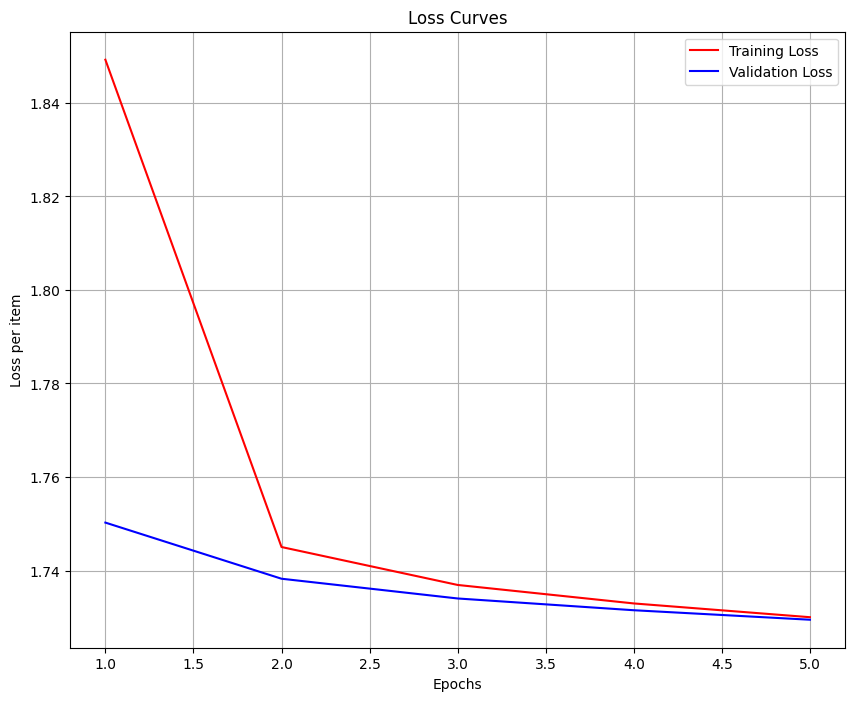

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.plot([i+1 for i in range(5)],training_losses,color='red',label="Training Loss")
plt.plot([i+1 for i in range(5)],validation_losses,color='blue',label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss per item")
plt.legend()
plt.grid(True)
plt.show()